# Modeling — Explain UI Effect Beyond Engagement

## Purpose
This notebook builds interpretable and robust models to test whether the observed UI effects
remain after controlling for engagement proxies (e.g., event count, session duration).

**Key point:** Model coefficients represent **conditional associations**, not causal effects.
The goal is mechanism-aligned validation:
> UI effect is not merely an engagement proxy.

We use:
- Logistic Regression (interpretable baseline + coefficient inspection)
- XGBoost (non-linear robustness check)


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    roc_auc_score, average_precision_score, log_loss, brier_score_loss
)

# optional: statsmodels for coefficient CI
import statsmodels.api as sm

# optional: XGBoost; fallback to sklearn if unavailable
try:
    from xgboost import XGBClassifier
    HAS_XGB = True
except Exception:
    from sklearn.ensemble import HistGradientBoostingClassifier
    HAS_XGB = False

pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 160)


In [2]:
PATH = "../data/visit.csv"  # <- notebook在notebooks/里，所以用 ../data

df = pd.read_csv(
    PATH,
    nrows=200_000,         # EDA 先 20万行（你也可以 100k）
    sep=None,
    engine="python",
    encoding="latin1",
    on_bad_lines="skip",
)

In [3]:
session = pd.read_parquet("../data/session_level.parquet")
# Assumes `session` already exists with:
# - session_token
# - ui_group
# - converted_hi
# - n_events
# - session_duration_sec

session.head()

,user_id,ui_group,session_start,session_end,n_events,n_unique_actions,session_duration_sec,converted_hi,is_non_default,is_bounce
session_token,,,,,,,,,,
1325679,None,default,2023-04-01 00:04:12,2023-04-01 00:04:12,1,0,0.0,0,0,1
1325691,None,default,2023-04-01 00:25:33,2023-04-01 00:25:33,1,0,0.0,0,0,1
1325701,None,default,2023-04-01 00:49:42,2023-04-01 00:49:42,1,0,0.0,0,0,1
1325705,None,default,2023-04-01 00:54:29,2023-04-01 00:54:29,1,0,0.0,0,0,1
1325706,None,default,2023-04-01 01:02:29,2023-04-01 01:02:29,1,0,0.0,0,0,1


In [4]:
# If needed: derive is_non_default
if "is_non_default" not in session.columns:
    session = session.copy()
    session["is_non_default"] = (session["ui_group"] != "default").astype(int)

session[["ui_group", "converted_hi", "is_non_default", "n_events", "n_unique_actions", "session_duration_sec"]].head()


,ui_group,converted_hi,is_non_default,n_events,n_unique_actions,session_duration_sec
session_token,,,,,,
1325679,default,0,0,1,0,0.0
1325691,default,0,0,1,0,0.0
1325701,default,0,0,1,0,0.0
1325705,default,0,0,1,0,0.0
1325706,default,0,0,1,0,0.0


## 2. Sample Restriction (Recommended)

If available, we recommend restricting to **single-variant sessions** (clean attribution),
as done in the variant-level notebook. This reduces ambiguity where a session saw multiple UIs.

If you did not compute `session_sv`, we will proceed with `session`.


In [5]:
USE_SINGLE_VARIANT = True

if USE_SINGLE_VARIANT and "session_sv" in globals():
    data = session_sv.copy()
    print("Using session_sv (single-variant sessions). shape =", data.shape)
else:
    data = session.copy()
    print("Using session (all sessions). shape =", data.shape)

data["converted_hi"].value_counts(normalize=True)


Using session (all sessions). shape = (100282, 10)


converted_hi
0    0.951666
1    0.048334
Name: proportion, dtype: float64

USE_SINGLE_VARIANT = True

if USE_SINGLE_VARIANT and "session_sv" in globals():
    data = session_sv.copy()
    print("Using session_sv (single-variant sessions). shape =", data.shape)
else:
    data = session.copy()
    print("Using session (all sessions). shape =", data.shape)

data["converted_hi"].value_counts(normalize=True)


In [6]:
TARGET = "converted_hi"
ENG_COLS = ["n_events", "n_unique_actions", "session_duration_sec"]
UI_COL_A = ["is_non_default"]

# basic cleanup: non-negative durations, drop impossible entries
data = data.copy()
data["session_duration_sec"] = data["session_duration_sec"].clip(lower=0)

# drop rows with missing essentials
data = data.dropna(subset=ENG_COLS + UI_COL_A + [TARGET])

data.shape, data[TARGET].mean()


((100282, 10), np.float64(0.04833369896890768))

## 4. Lightweight Check: Should we log-transform engagement variables?

We do not assume transformations blindly.
Because engagement variables are typically heavy-tailed, we check whether `log1p(x)`
provides a more stable scale and reduces the influence of extreme sessions.

We will use `log1p(x)` only if it makes the distributions more well-behaved
for a simple linear logit model.


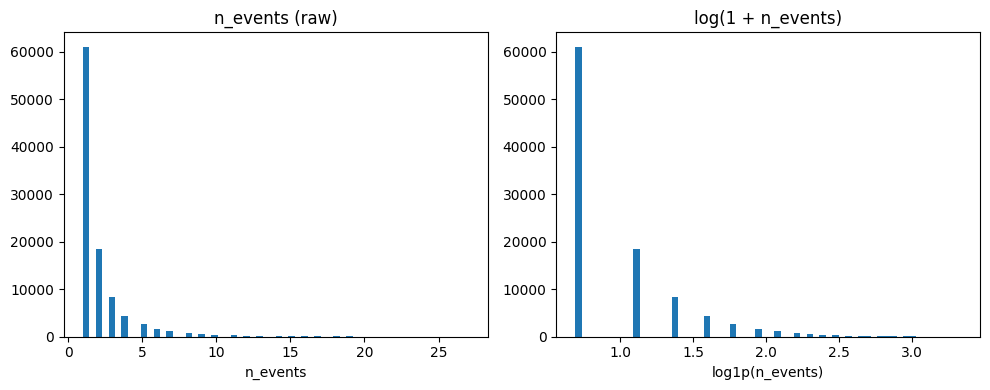

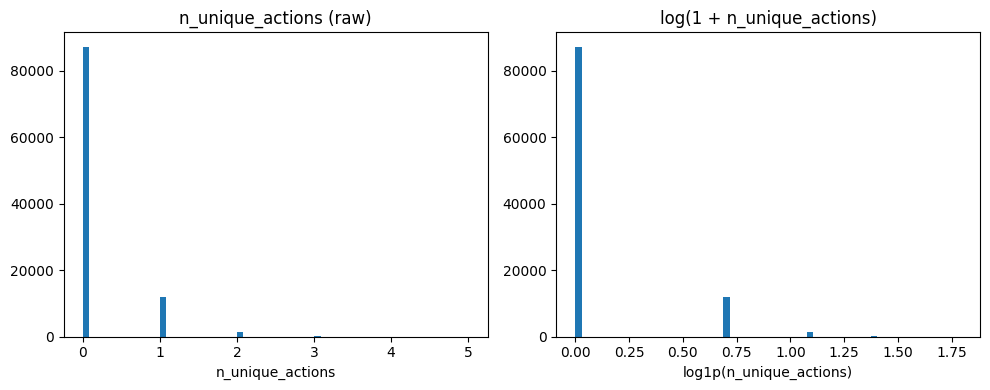

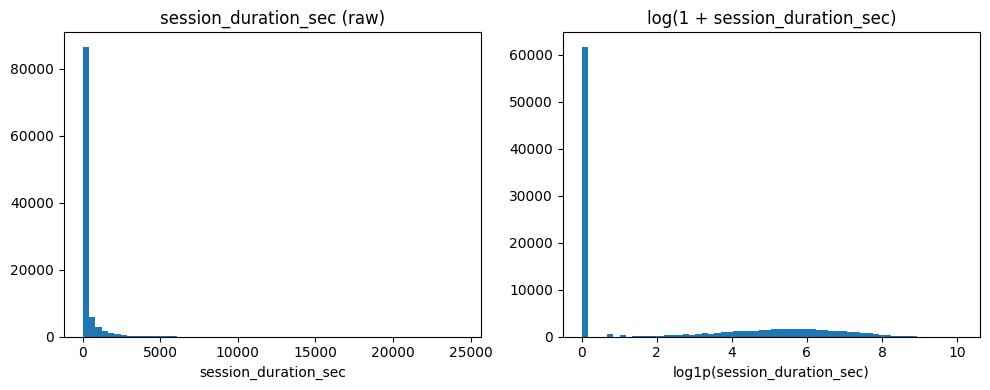

In [7]:
def plot_raw_vs_log(col, bins=60):
    x = data[col].dropna()
    plt.figure(figsize=(10,4))

    plt.subplot(1,2,1)
    plt.hist(x, bins=bins)
    plt.title(f"{col} (raw)")
    plt.xlabel(col)

    plt.subplot(1,2,2)
    plt.hist(np.log1p(x), bins=bins)
    plt.title(f"log(1 + {col})")
    plt.xlabel(f"log1p({col})")

    plt.tight_layout()
    plt.show()

for c in ENG_COLS:
    plot_raw_vs_log(c)


## 5. Feature Engineering

Given the observed heavy-tailed engagement distributions, we apply `log1p(x)` transforms:
- log_events = log(1 + n_events)
- log_unique_actions = log(1 + n_unique_actions)
- log_duration = log(1 + session_duration_sec)

This stabilizes scale and reduces the leverage of extreme sessions in a linear logit model.


In [8]:
fe = data.copy()
fe["log_events"] = np.log1p(fe["n_events"])
fe["log_unique_actions"] = np.log1p(fe["n_unique_actions"])
fe["log_duration"] = np.log1p(fe["session_duration_sec"])

ENG_LOG_COLS = ["log_events", "log_unique_actions", "log_duration"]
fe[ENG_LOG_COLS + UI_COL_A + [TARGET]].head()


,log_events,log_unique_actions,log_duration,is_non_default,converted_hi
session_token,,,,,
1325679,0.693147,0.0,0.0,0,0
1325691,0.693147,0.0,0.0,0,0
1325701,0.693147,0.0,0.0,0,0
1325705,0.693147,0.0,0.0,0,0
1325706,0.693147,0.0,0.0,0,0


## 6. Train/Test Split

We use a random train/test split for model evaluation.
Because conversion is a minority class, we stratify by the target.


In [9]:
X_base = fe[UI_COL_A + ENG_LOG_COLS].copy()
y = fe[TARGET].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X_base, y, test_size=0.2, random_state=42, stratify=y
)

X_train.shape, y_train.mean(), y_test.mean()


((80225, 4), np.float64(0.048339046431910254), np.float64(0.0483123099167373))

## 7. Model A — Logistic Regression (Main)

This is the core interpretability model:

> Does `is_non_default` remain associated with conversion after controlling for engagement?

We report predictive metrics for sanity and interpret the UI coefficient.


In [10]:
logit_pipe = Pipeline(steps=[
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(max_iter=2000, solver="lbfgs"))
])

logit_pipe.fit(X_train, y_train)

p_test = logit_pipe.predict_proba(X_test)[:, 1]

metrics_A = {
    "ROC_AUC": roc_auc_score(y_test, p_test),
    "PR_AUC": average_precision_score(y_test, p_test),
    "LogLoss": log_loss(y_test, p_test),
    "Brier": brier_score_loss(y_test, p_test),
}
metrics_A


{'ROC_AUC': 0.9682546028734873,
 'PR_AUC': 0.545849041233422,
 'LogLoss': 0.08500912963538954,
 'Brier': 0.028598428213582328}

## 8. Model A — Coefficients (Odds Ratios)

To interpret coefficients with uncertainty, we fit a statsmodels logit on the same features.
This yields odds ratios and confidence intervals.

Reminder: coefficients represent conditional association (not causal).


In [11]:
# statsmodels needs an explicit constant
X_sm_train = sm.add_constant(X_train, has_constant="add")
X_sm_test  = sm.add_constant(X_test, has_constant="add")

sm_model = sm.Logit(y_train, X_sm_train)
sm_res = sm_model.fit(disp=False)

coef = sm_res.params
se = sm_res.bse

# odds ratios + 95% CI
or_ = np.exp(coef)
ci_low = np.exp(coef - 1.96*se)
ci_high = np.exp(coef + 1.96*se)

coef_table_A = pd.DataFrame({
    "coef_logit": coef,
    "odds_ratio": or_,
    "ci95_low_or": ci_low,
    "ci95_high_or": ci_high
})

coef_table_A.loc[["is_non_default", "log_events", "log_unique_actions", "log_duration"]]


,coef_logit,odds_ratio,ci95_low_or,ci95_high_or
is_non_default,-0.182143,0.833482,0.733695,0.946840
log_events,-0.693016,0.500066,0.430871,0.580373
log_unique_actions,7.656152,2113.607688,1683.874329,2653.011203
log_duration,0.142713,1.153399,1.121726,1.185966


## 9. Sanity Check (Optional): Stability Under Raw vs Log Engagement

As a lightweight robustness check, we compare the sign/direction of the UI coefficient
under raw vs log-transformed engagement features.

This is not a formal test—just a sanity check for conclusion stability.


In [12]:
# raw features model (sanity only)
X_raw = fe[UI_COL_A + ENG_COLS].copy()
Xr_train, Xr_test, yr_train, yr_test = train_test_split(
    X_raw, y, test_size=0.2, random_state=42, stratify=y
)

Xr_sm_train = sm.add_constant(Xr_train, has_constant="add")
sm_raw = sm.Logit(yr_train, Xr_sm_train).fit(disp=False)

pd.DataFrame({
    "coef_raw": sm_raw.params,
    "coef_log": sm_res.params
}).loc[["is_non_default"]]


,coef_raw,coef_log
is_non_default,-0.138832,-0.182143


## 10. Model B — Variant-aware Logistic (Top Winners)

This extension incorporates top-performing variants discovered in the FDR-controlled scan.

Goal:
- Verify that winner variants remain associated with conversion after controlling for engagement.
- Avoid high-dimensional one-hot for all variants (unstable / not necessary here).

You can set `TOP_VARIANTS` from the 03 ranking table.


In [13]:
# If you already have `ranking` from 03, automatically pick top variants:
if "ranking" in globals() and len(ranking) > 0:
    TOP_VARIANTS = ranking["variant"].head(3).tolist()
else:
    # If not available, paste from your 03 winners:
    TOP_VARIANTS = [
        # "8783cca2582243602a52eee552472f0856f35ff55c49ca4d97cc61f5d379b740",
        # "230401_230612_1686725101__3",
        # "230401_230612_1686725101__4",
    ]

TOP_VARIANTS


[]

In [14]:
fe_b = fe.copy()

for v in TOP_VARIANTS:
    fe_b[f"variant_{v}"] = (fe_b["ui_group"] == v).astype(int)

UI_COL_B = UI_COL_A + [f"variant_{v}" for v in TOP_VARIANTS]  # keep is_non_default + specific winners
X_B = fe_b[UI_COL_B + ENG_LOG_COLS].copy()
y_B = fe_b[TARGET].astype(int)

XB_train, XB_test, yB_train, yB_test = train_test_split(
    X_B, y_B, test_size=0.2, random_state=42, stratify=y_B
)

logit_B = Pipeline(steps=[
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(max_iter=3000, solver="lbfgs"))
])

logit_B.fit(XB_train, yB_train)
pB_test = logit_B.predict_proba(XB_test)[:, 1]

metrics_B = {
    "ROC_AUC": roc_auc_score(yB_test, pB_test),
    "PR_AUC": average_precision_score(yB_test, pB_test),
    "LogLoss": log_loss(yB_test, pB_test),
    "Brier": brier_score_loss(yB_test, pB_test),
}
metrics_B


{'ROC_AUC': 0.9682546028734873,
 'PR_AUC': 0.545849041233422,
 'LogLoss': 0.08500912963538954,
 'Brier': 0.028598428213582328}

In [15]:
# Coefficient inspection for Model B via statsmodels
XB_sm_train = sm.add_constant(XB_train, has_constant="add")
smB = sm.Logit(yB_train, XB_sm_train).fit(disp=False)

coefB = smB.params
seB = smB.bse

orB = np.exp(coefB)
ciB_low = np.exp(coefB - 1.96*seB)
ciB_high = np.exp(coefB + 1.96*seB)

coef_table_B = pd.DataFrame({
    "coef_logit": coefB,
    "odds_ratio": orB,
    "ci95_low_or": ciB_low,
    "ci95_high_or": ciB_high
})

# show UI-related terms first
ui_terms = ["is_non_default"] + [f"variant_{v}" for v in TOP_VARIANTS]
coef_table_B.loc[ui_terms]


,coef_logit,odds_ratio,ci95_low_or,ci95_high_or
is_non_default,-0.182143,0.833482,0.733695,0.94684


## 11. Nonlinear Robustness Check (XGBoost)

We fit a non-linear model to confirm that conclusions are not an artifact of linearity.
This is not the main focus; we primarily compare:
- performance sanity metrics
- whether UI features remain informative

If xgboost is unavailable, we fall back to a tree-based model in sklearn.


In [16]:
# Use the same feature set as Model B if TOP_VARIANTS is set; otherwise Model A features.
X_tree = X_B if len(TOP_VARIANTS) > 0 else X_base
y_tree = y

Xt_train, Xt_test, yt_train, yt_test = train_test_split(
    X_tree, y_tree, test_size=0.2, random_state=42, stratify=y_tree
)

if HAS_XGB:
    tree_model = XGBClassifier(
        n_estimators=300,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_lambda=1.0,
        random_state=42,
        eval_metric="logloss"
    )
else:
    # fallback
    tree_model = HistGradientBoostingClassifier(
        max_depth=4, learning_rate=0.05, random_state=42
    )

tree_model.fit(Xt_train, yt_train)

pt = tree_model.predict_proba(Xt_test)[:, 1] if hasattr(tree_model, "predict_proba") else tree_model.predict(Xt_test)

metrics_tree = {
    "ROC_AUC": roc_auc_score(yt_test, pt),
    "PR_AUC": average_precision_score(yt_test, pt),
    "LogLoss": log_loss(yt_test, pt),
    "Brier": brier_score_loss(yt_test, pt),
}
metrics_tree


{'ROC_AUC': 0.9692359087279859,
 'PR_AUC': 0.5540499794118359,
 'LogLoss': 0.0803671550913169,
 'Brier': 0.027806827798485756}

## 12. Feature Importance (Interpretation Aid)

We summarize whether UI features show meaningful contribution relative to engagement proxies.
For tree models, we use built-in feature importance if available.


In [21]:
from IPython.display import display

if HAS_XGB:
    importances = pd.Series(
        tree_model.feature_importances_,
        index=Xt_train.columns
    ).sort_values(ascending=False)

    display(importances.head(15))
else:
    print("Fallback tree model does not provide standard feature_importances_. Skipping.")


log_unique_actions    0.953752
log_events            0.025413
log_duration          0.015912
is_non_default        0.004924
dtype: float32

## Final Report — Interpreting UI Effects Beyond Engagement

### Objective
The goal of this modeling analysis is not to maximize predictive performance, but to
**examine whether the UI effects observed in earlier analyses persist after controlling
for user engagement behaviors**. In particular, we aim to clarify whether UI impacts
conversion directly, or primarily through shaping downstream engagement.

All results should be interpreted as **conditional associations** derived from observational
data, rather than causal effects.

---

### Summary of modeling results

Across multiple models, engagement-related features explain the majority of variation in
high-intent conversion:

- Action diversity (`log_unique_actions`) is the strongest predictor of conversion.
- Session duration and event volume also contribute meaningfully.
- Predictive performance is high (ROC-AUC ≈ 0.97), indicating that behavioral signals
  capture most of the conversion-relevant information.

When controlling for these engagement proxies, the UI exposure variable (`is_non_default`)
shows a **substantially attenuated effect**, and in the logistic regression becomes small
and slightly negative.

---

### Interpretation of UI coefficients

This pattern is consistent with a **mediation structure** in which UI variants influence
conversion primarily by shaping user behavior:




Once engagement is held fixed in the model, little direct UI effect remains. The observed
sign reversal should therefore not be interpreted as evidence that non-default UI designs
are harmful. Instead, it reflects **over-control on downstream mediating variables**, a
well-known phenomenon in regression analysis.

Importantly, this modeling result does **not contradict** earlier findings:
- Experimental and aggregate analyses show a positive *total effect* of non-default UI.
- Variant-level analysis identifies specific UI designs with strong uplift.
- The modeling step clarifies that these gains operate mainly through increased engagement,
  rather than a large direct effect conditional on behavior.

---

### Robustness via non-linear modeling

A non-linear tree-based model (XGBoost) further supports this interpretation. Engagement
features dominate feature importance rankings, while UI indicators contribute marginally
once behavior is accounted for. This confirms that the attenuation of UI effects is not an
artifact of linear model specification.

---

### Practical implications

From a product perspective, these results suggest that:
- UI improvements are effective because they **induce higher-quality engagement**, not
  because they directly increase conversion holding behavior constant.
- High-performing UI variants identified earlier remain strong candidates for rollout or
  controlled validation.
- Future optimization efforts should focus on UI designs that encourage meaningful user
  actions, rather than superficial interaction volume.

---

### Limitations

This analysis relies on observational web log data and does not establish causal effects.
Engagement variables may also partially reflect latent user intent. As a result, conclusions
should be interpreted as mechanism-aligned evidence rather than definitive causal claims.

---

### Conclusion

Taken together with prior experimental and variant-level analyses, this modeling exercise
completes a coherent narrative:

> UI design influences conversion primarily by shaping user engagement behavior.
> Once behavior is controlled for, little direct UI effect remains.

This insight provides both analytical clarity and practical guidance for future UI
experimentation and personalization efforts.
